# Prototype Inference — SimCLR / SupCon
### Rust / Corrosion Detection

Supports three encoder options:
- `simclr` — SimCLR pretrained (93.86% val acc)
- `supcon` — SupCon from scratch, h_raw (92.78% val acc)
- `supcon_2stage` — SimCLR init → SupCon fine-tune, h_l2 (89.53% val acc)

**Steps:**
- **Section 1** — Setup & Config
- **Section 2** — Build Bundle (run once per model)
- **Section 3** — Single Image Inference
- **Section 4** — Folder Inference
- **Section 5** — Model Comparison (SupCon vs SupCon 2-Stage)

## Section 1 — Setup & Config

In [1]:
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
# Config

DEVICE      = torch.device("mps" if torch.backends.mps.is_available()
                           else "cuda" if torch.cuda.is_available()
                           else "cpu")

# Choose model: "simclr", "supcon", "supcon_2stage"
MODEL_CHOICE = "supcon"

CKPT_MAP = {
    "simclr"       : "simclr_best.pt",
    "supcon"       : "supcon_best.pt",
    "supcon_2stage": "supcon_2stage_best.pt",
}

# L2 normalize features for supcon_2stage, raw for simclr and supcon
NORMALIZE_MAP = {
    "simclr"       : True,
    "supcon"       : False,   # h_raw is best for SupCon scratch
    "supcon_2stage": True,    # h_l2 is best for 2-stage
}

CKPT_PATH   = Path(CKPT_MAP[MODEL_CHOICE])
BUNDLE_PATH = Path(f"bundle_{MODEL_CHOICE}.pt")
NORMALIZE_H = NORMALIZE_MAP[MODEL_CHOICE]

TRAIN_DIR   = Path("rust_dataset/train")
IMG_SIZE    = 224
THRESHOLD   = 0.60
NUM_WORKERS = 0

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print(f"Model    : {MODEL_CHOICE}")
print(f"Checkpoint: {CKPT_PATH}")
print(f"Device   : {DEVICE}")

Model    : supcon
Checkpoint: supcon_best.pt
Device   : mps


In [3]:
# Model definitions

class SimCLR(nn.Module):
    def __init__(self, proj_dim=128):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.encoder   = nn.Sequential(*list(base.children())[:-1])
        self.feat_dim  = base.fc.in_features
        self.projector = nn.Sequential(
            nn.Linear(self.feat_dim, self.feat_dim),
            nn.ReLU(),
            nn.Linear(self.feat_dim, proj_dim),
        )

    def forward(self, x):
        h = self.encoder(x).squeeze(-1).squeeze(-1)
        z = self.projector(h)
        return h, F.normalize(z, dim=1)


class ResNet18SupCon(nn.Module):
    def __init__(self, proj_dim=128):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.encoder   = nn.Sequential(*list(base.children())[:-1])
        self.feat_dim  = base.fc.in_features
        self.projector = nn.Sequential(
            nn.Linear(self.feat_dim, self.feat_dim),
            nn.ReLU(),
            nn.Linear(self.feat_dim, proj_dim),
        )

    def forward(self, x):
        h = self.encoder(x).squeeze(-1).squeeze(-1)
        z = self.projector(h)
        return h, F.normalize(z, dim=1)


def load_model(model_choice, ckpt_path):
    if model_choice == "simclr":
        model = SimCLR().to(DEVICE)
    else:
        model = ResNet18SupCon().to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
    model.eval()
    return model

In [4]:
# Transforms and utilities

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def l2_normalize(Z, eps=1e-12):
    return Z / (Z.norm(dim=1, keepdim=True) + eps)

def extract_features(model, dataloader, normalize_h=False):
    model.eval()
    all_h, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(DEVICE)
            h, _   = model(images)
            if normalize_h:
                h = l2_normalize(h)
            all_h.append(h.cpu())
            all_labels.append(labels.cpu())
    return torch.cat(all_h, dim=0), torch.cat(all_labels, dim=0)

def compute_prototypes(H, y, class_names):
    protos = []
    for c in range(len(class_names)):
        mask  = (y == c)
        proto = l2_normalize(H[mask]).mean(dim=0)
        protos.append(proto)
    return l2_normalize(torch.stack(protos, dim=0))

print("Utilities ready.")

Utilities ready.


## Section 2 — Build Bundle

Run this once to compute class prototypes from the training set and save the bundle.
Skip if bundle already exists.

In [5]:
# Build bundle — load model, extract train features, compute prototypes

print(f"Loading {MODEL_CHOICE} checkpoint from {CKPT_PATH} ...")
model = load_model(MODEL_CHOICE, CKPT_PATH)
print("Checkpoint loaded.")

Loading supcon checkpoint from supcon_best.pt ...
Checkpoint loaded.


In [6]:
# Extract training features and compute prototypes

ds = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)
dl = DataLoader(ds, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)

H, y        = extract_features(model, dl, normalize_h=NORMALIZE_H)
class_names = ds.classes
prototypes  = compute_prototypes(H, y, class_names)

print(f"Classes    : {class_names}")
print(f"Features   : {H.shape}")
print(f"Prototypes : {prototypes.shape}")
print(f"Normalized : {NORMALIZE_H}")

Classes    : ['CORROSION', 'HARD_NEGATIVE', 'NOCORROSION']
Features   : torch.Size([2472, 512])
Prototypes : torch.Size([3, 512])
Normalized : False


In [7]:
# Save bundle

bundle = {
    "model_state_dict": model.state_dict(),
    "prototypes"      : prototypes,
    "threshold"       : THRESHOLD,
    "class_names"     : class_names,
    "normalize_h"     : NORMALIZE_H,
    "model_choice"    : MODEL_CHOICE,
}

torch.save(bundle, BUNDLE_PATH)
print(f"Bundle saved to {BUNDLE_PATH}")

Bundle saved to bundle_supcon.pt


### Build All Bundles at Once

Run the cell below to build `bundle_supcon.pt` and `bundle_supcon_2stage.pt` in one shot.
Required before running Section 5 (Model Comparison).

In [8]:
# Build bundles for all three models (run once)

BUILD_MODELS = ["simclr", "supcon", "supcon_2stage"]

for mc in BUILD_MODELS:
    ckpt_path   = Path(CKPT_MAP[mc])
    bundle_path = Path(f"bundle_{mc}.pt")
    norm_h      = NORMALIZE_MAP[mc]

    if bundle_path.exists():
        print(f"[{mc}] bundle already exists at {bundle_path} — skipping.")
        continue

    print(f"\n[{mc}] Loading checkpoint from {ckpt_path} ...")
    mdl = load_model(mc, ckpt_path)

    ds  = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)
    dl  = DataLoader(ds, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)

    H, y      = extract_features(mdl, dl, normalize_h=norm_h)
    cls_names = ds.classes
    protos    = compute_prototypes(H, y, cls_names)

    bndl = {
        "model_state_dict": mdl.state_dict(),
        "prototypes"      : protos,
        "threshold"       : THRESHOLD,
        "class_names"     : cls_names,
        "normalize_h"     : norm_h,
        "model_choice"    : mc,
    }
    torch.save(bndl, bundle_path)
    print(f"[{mc}] Bundle saved → {bundle_path}")
    print(f"       Classes: {cls_names}  |  Features: {H.shape}  |  Normalize: {norm_h}")

print("\nDone.")

[simclr] bundle already exists at bundle_simclr.pt — skipping.
[supcon] bundle already exists at bundle_supcon.pt — skipping.
[supcon_2stage] bundle already exists at bundle_supcon_2stage.pt — skipping.

Done.


## Section 3 — Single Image Inference

In [9]:
# Load bundle

bundle      = torch.load(BUNDLE_PATH, map_location=DEVICE, weights_only=False)
model       = load_model(MODEL_CHOICE, CKPT_PATH)
prototypes  = bundle["prototypes"].to(DEVICE)
threshold   = bundle["threshold"]
class_names = bundle["class_names"]
normalize_h = bundle["normalize_h"]

print(f"Model    : {MODEL_CHOICE}")
print(f"Classes  : {class_names}")
print(f"Threshold: {threshold}")
print(f"Normalize: {normalize_h}")

Model    : supcon
Classes  : ['CORROSION', 'HARD_NEGATIVE', 'NOCORROSION']
Threshold: 0.6
Normalize: False


In [10]:
# Predict single image function

def predict_single_image(image_path, show=True, save_annotated=True):
    image_path = Path(image_path)
    image      = Image.open(image_path).convert("RGB")
    x          = eval_transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        h, _  = model(x)
        if normalize_h:
            h = l2_normalize(h)
        sims  = h @ prototypes.T

        score, pred = sims.max(dim=1)
        score       = float(score.item())
        pred        = int(pred.item())

    nearest_class = class_names[pred]
    accepted      = score >= threshold and nearest_class != "HARD_NEGATIVE"
    label         = nearest_class if accepted else "REJECT"

    result = {
        "image"        : str(image_path),
        "label"        : label,
        "accepted"     : accepted,
        "nearest_class": nearest_class,
        "score"        : round(score, 4),
        "threshold"    : threshold,
        "similarities" : {cls: round(float(s), 4)
                           for cls, s in zip(class_names, sims.squeeze(0).cpu())},
    }

    if show:
        status = "ACCEPTED" if accepted else "REJECTED"
        color  = "red" if label == "CORROSION" else ("green" if accepted else "gray")

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        axes[0].imshow(image)
        axes[0].set_title(f"{label}  ({status})", color=color, fontsize=13, fontweight="bold")
        axes[0].axis("off")

        classes = list(result["similarities"].keys())
        scores  = list(result["similarities"].values())
        colors  = ["tomato" if c == nearest_class else "steelblue" for c in classes]
        axes[1].barh(classes, scores, color=colors)
        axes[1].axvline(threshold, color="black", linestyle="--", label=f"threshold={threshold}")
        axes[1].set_xlabel("Cosine Similarity")
        axes[1].set_title("Prototype Similarities")
        axes[1].legend()
        axes[1].set_xlim(0, 1)

        plt.suptitle(f"{image_path.name}  |  score={score:.4f}  |  model={MODEL_CHOICE}", fontsize=11)
        plt.tight_layout()
        plt.show()

    if save_annotated and accepted:
        out_dir   = Path("annotated_results")
        out_dir.mkdir(exist_ok=True)
        annotated = image.copy()
        draw      = ImageDraw.Draw(annotated)
        color_box = "red" if label == "CORROSION" else "green"
        draw.rectangle([0, 0, annotated.width, 30], fill=color_box)
        draw.text((5, 5), f"{label}  {score:.2f}", fill="white")
        annotated.save(out_dir / image_path.name)
        result["annotated_path"] = str(out_dir / image_path.name)

    return result

In [11]:
# Run on a single image — change the path below

# IMAGE_PATH = "testing1.jpg"   # <-- update this

# result = predict_single_image(IMAGE_PATH)
# print(result)

## Section 4 — Folder Inference

In [12]:
# Predict all images in a folder

def predict_folder(folder_path):
    folder  = Path(folder_path)
    images  = sorted(folder.glob("*.jpg")) + sorted(folder.glob("*.png"))
    results = []

    print(f"Running inference on {len(images)} images ...")
    for img_path in images:
        result = predict_single_image(img_path, show=False, save_annotated=True)
        status = "ACCEPTED" if result["accepted"] else "REJECTED"
        print(f"  {img_path.name:30s} | {result['label']:12s} | score={result['score']:.4f} | {status}")
        results.append(result)

    accepted  = [r for r in results if r["accepted"]]
    rejected  = [r for r in results if not r["accepted"]]
    corrosion = [r for r in accepted if r["label"] == "CORROSION"]

    print(f"{'='*50}")
    print(f"Total    : {len(results)}")
    print(f"Accepted : {len(accepted)}")
    print(f"Rejected : {len(rejected)}")
    if accepted:
        print(f"  CORROSION   : {len(corrosion)}")
        print(f"  NOCORROSION : {len(accepted) - len(corrosion)}")

    return results

In [13]:
# Run on a folder — change the path below

# FOLDER_PATH = "rust_dataset/test/HARD_NEGATIVE"   # <-- update this

# results = predict_folder(FOLDER_PATH)

## Section 5 — Model Comparison (SupCon vs SupCon 2-Stage)

Runs both `supcon` and `supcon_2stage` on the same image side-by-side.
Make sure you have built bundles for both models first (Section 2).

[simclr]  CORROSION (ACCEPTED)  decision_score=0.7138  nearest=CORROSION
[supcon]  CORROSION (ACCEPTED)  decision_score=20.1965  nearest=CORROSION
[supcon_2stage]  CORROSION (ACCEPTED)  decision_score=0.7768  nearest=CORROSION


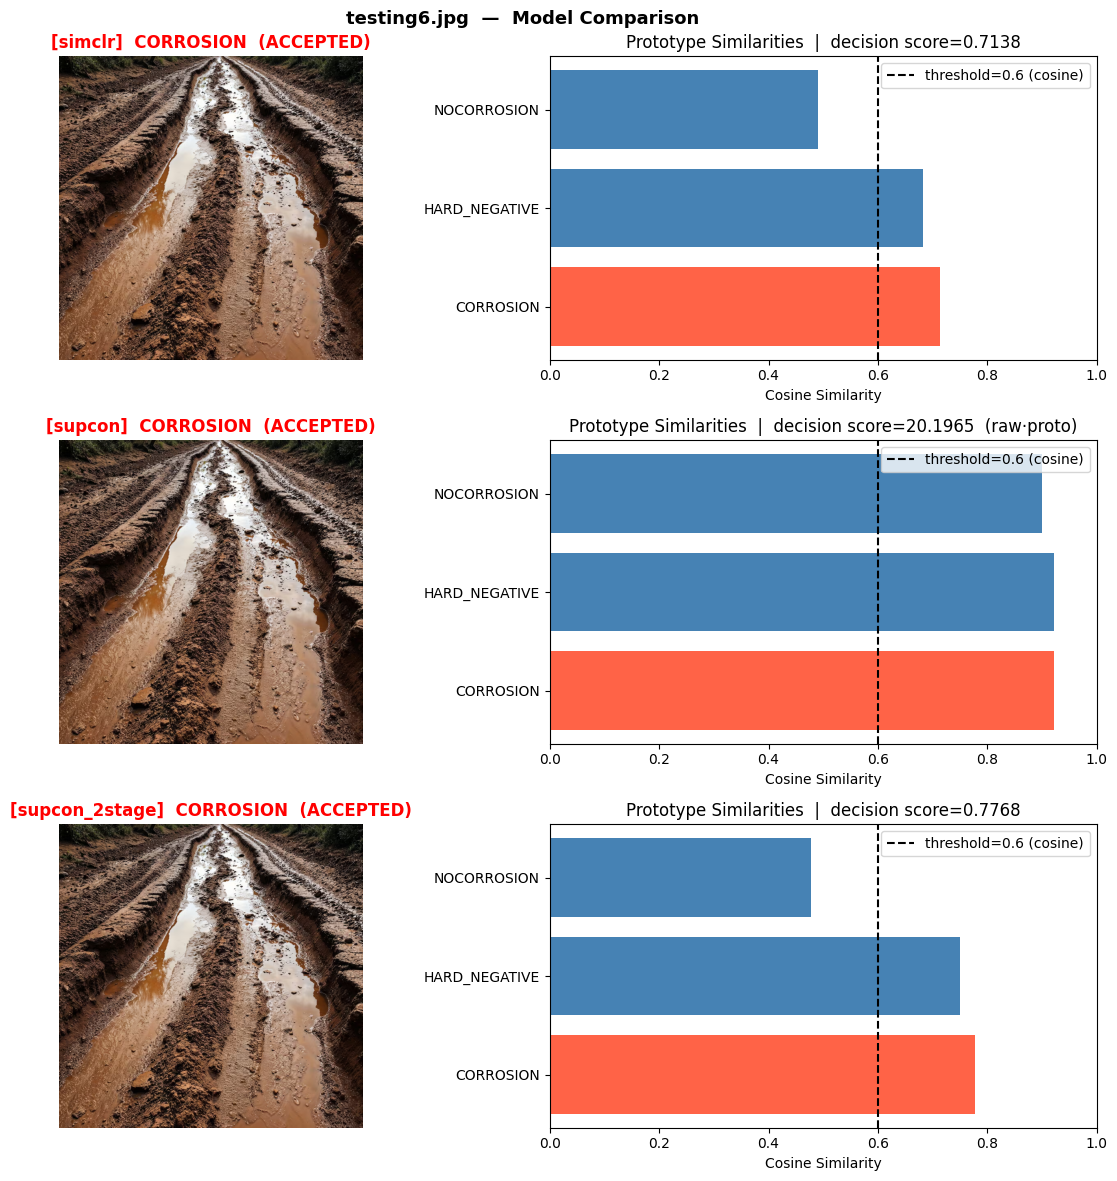

In [14]:
# Compare SimCLR vs SupCon (scratch) vs SupCon 2-Stage on the same image

COMPARE_IMAGE     = "testing6.jpg"                          # <-- update this
MODELS_TO_COMPARE = ["simclr", "supcon", "supcon_2stage"]   # all three models

CKPT_MAP_CMP = {
    "simclr"       : "simclr_best.pt",
    "supcon"       : "supcon_best.pt",
    "supcon_2stage": "supcon_2stage_best.pt",
}
NORMALIZE_MAP_CMP = {
    "simclr"       : True,
    "supcon"       : False,
    "supcon_2stage": True,
}

def run_comparison(image_path, models_to_compare):
    image_path = Path(image_path)
    image      = Image.open(image_path).convert("RGB")
    x          = eval_transform(image).unsqueeze(0).to(DEVICE)

    n         = len(models_to_compare)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
    if n == 1:
        axes = [axes]

    for row, mc in enumerate(models_to_compare):
        ckpt_path   = Path(CKPT_MAP_CMP[mc])
        bundle_path = Path(f"bundle_{mc}.pt")
        norm_h      = NORMALIZE_MAP_CMP[mc]

        bndl      = torch.load(bundle_path, map_location=DEVICE, weights_only=False)
        mdl       = load_model(mc, ckpt_path)
        protos    = bndl["prototypes"].to(DEVICE)
        thresh    = bndl["threshold"]
        cls_names = bndl["class_names"]

        with torch.no_grad():
            h, _ = mdl(x)

            # --- decision: use raw or normalized h as the bundle was built ---
            h_decision    = l2_normalize(h) if norm_h else h
            sims_decision = h_decision @ protos.T
            score, pred   = sims_decision.max(dim=1)
            score         = float(score.item())
            pred          = int(pred.item())

            # --- display: always use cosine similarity (0–1 range) ---
            h_display    = l2_normalize(h)
            sims_display = h_display @ protos.T   # protos are already unit vectors

        nearest_class = cls_names[pred]
        accepted      = score >= thresh and nearest_class != "HARD_NEGATIVE"
        label         = nearest_class if accepted else "REJECT"
        status        = "ACCEPTED" if accepted else "REJECTED"
        color         = "red" if label == "CORROSION" else ("green" if accepted else "gray")

        # Image panel
        axes[row][0].imshow(image)
        axes[row][0].set_title(
            f"[{mc}]  {label}  ({status})",
            color=color, fontsize=12, fontweight="bold"
        )
        axes[row][0].axis("off")

        # Bar chart panel — always shows cosine similarity for readability
        sim_dict   = {c: round(float(s), 4)
                      for c, s in zip(cls_names, sims_display.squeeze(0).cpu())}
        bar_colors = ["tomato" if c == nearest_class else "steelblue" for c in sim_dict]
        axes[row][1].barh(list(sim_dict.keys()), list(sim_dict.values()), color=bar_colors)
        axes[row][1].axvline(0.6, color="black", linestyle="--", label="threshold=0.6 (cosine)")
        axes[row][1].set_xlabel("Cosine Similarity")
        axes[row][1].set_title(
            f"Prototype Similarities  |  decision score={score:.4f}"
            + ("  (raw·proto)" if not norm_h else "")
        )
        axes[row][1].legend()
        axes[row][1].set_xlim(0, 1)

        print(f"[{mc}]  {label} ({status})  decision_score={score:.4f}  nearest={nearest_class}")

    plt.suptitle(f"{image_path.name}  —  Model Comparison", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


run_comparison(COMPARE_IMAGE, MODELS_TO_COMPARE)

## Section 6 — Linear Probe Comparison

Trains a small `Linear(512 → num_classes)` head on top of each **frozen** encoder using the training set, then evaluates on the test set. Shows how well each encoder's features are linearly separable — a direct measure of representation quality.


[simclr] Extracting features ...
       Train: torch.Size([2472, 512])  |  Test: torch.Size([764, 512])  |  Classes: ['CORROSION', 'HARD_NEGATIVE', 'NOCORROSION']
[simclr] Training linear probe (50 epochs) ...
[simclr] Best test accuracy: 87.96%

[supcon] Extracting features ...
       Train: torch.Size([2472, 512])  |  Test: torch.Size([764, 512])  |  Classes: ['CORROSION', 'HARD_NEGATIVE', 'NOCORROSION']
[supcon] Training linear probe (50 epochs) ...
[supcon] Best test accuracy: 89.53%

[supcon_2stage] Extracting features ...
       Train: torch.Size([2472, 512])  |  Test: torch.Size([764, 512])  |  Classes: ['CORROSION', 'HARD_NEGATIVE', 'NOCORROSION']
[supcon_2stage] Training linear probe (50 epochs) ...
[supcon_2stage] Best test accuracy: 84.03%


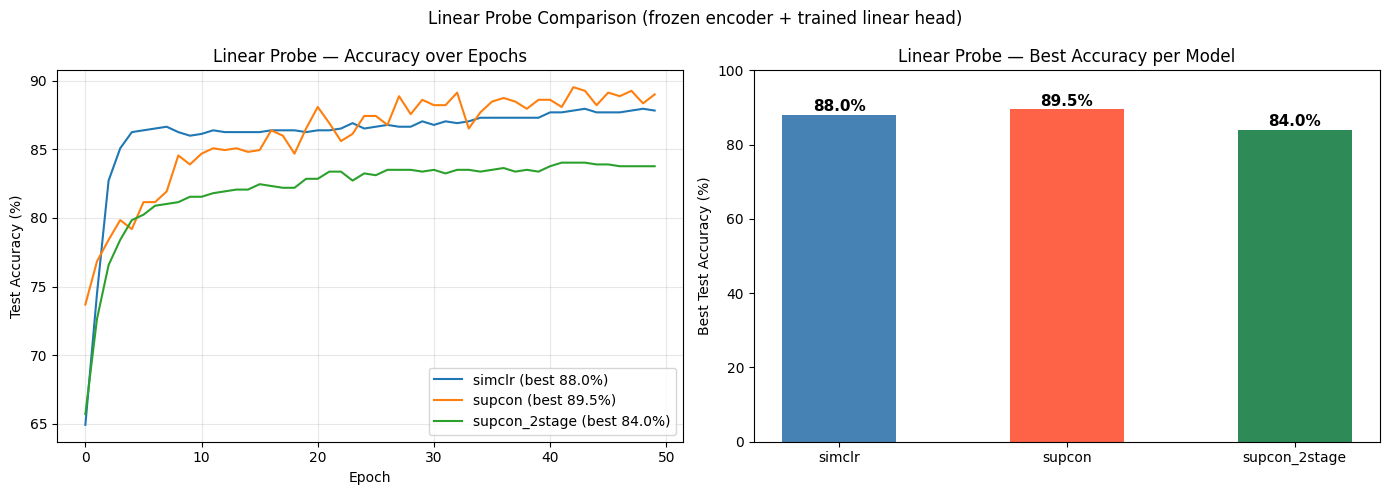


Summary:
  simclr                best acc = 87.96%
  supcon                best acc = 89.53%
  supcon_2stage         best acc = 84.03%


In [15]:
# Linear Probe — train a frozen-encoder classifier for each model and compare

from torch.utils.data import TensorDataset
from torch.optim import Adam

TEST_DIR         = Path("rust_dataset/test")
PROBE_EPOCHS     = 50
PROBE_LR         = 1e-3
PROBE_BATCH      = 64

PROBE_MODELS = ["simclr", "supcon", "supcon_2stage"]

# ── helpers ──────────────────────────────────────────────────────────────────

def extract_all_features(model_choice):
    """Extract (H_train, y_train, H_test, y_test, class_names) for a given model."""
    norm_h = NORMALIZE_MAP[model_choice]
    mdl    = load_model(model_choice, Path(CKPT_MAP[model_choice]))

    ds_train = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)
    ds_test  = datasets.ImageFolder(TEST_DIR,  transform=eval_transform)

    dl_train = DataLoader(ds_train, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)
    dl_test  = DataLoader(ds_test,  batch_size=64, shuffle=False, num_workers=NUM_WORKERS)

    H_train, y_train = extract_features(mdl, dl_train, normalize_h=norm_h)
    H_test,  y_test  = extract_features(mdl, dl_test,  normalize_h=norm_h)

    return H_train, y_train, H_test, y_test, ds_train.classes


def train_linear_probe(H_train, y_train, H_test, y_test, num_classes):
    """Train a Linear head on frozen features and return test accuracy per epoch."""
    probe     = nn.Linear(H_train.shape[1], num_classes).to(DEVICE)
    optimizer = Adam(probe.parameters(), lr=PROBE_LR)
    criterion = nn.CrossEntropyLoss()

    train_ds = TensorDataset(H_train, y_train)
    train_dl = DataLoader(train_ds, batch_size=PROBE_BATCH, shuffle=True)

    probe.train()
    accs = []
    for epoch in range(PROBE_EPOCHS):
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(probe(xb), yb)
            loss.backward()
            optimizer.step()

        # eval
        probe.eval()
        with torch.no_grad():
            preds = probe(H_test.to(DEVICE)).argmax(dim=1).cpu()
        acc = (preds == y_test).float().mean().item() * 100
        accs.append(acc)
        probe.train()

    return probe, accs


# ── run ───────────────────────────────────────────────────────────────────────

results_probe = {}

for mc in PROBE_MODELS:
    print(f"\n[{mc}] Extracting features ...")
    H_tr, y_tr, H_te, y_te, cls_names = extract_all_features(mc)
    print(f"       Train: {H_tr.shape}  |  Test: {H_te.shape}  |  Classes: {cls_names}")

    print(f"[{mc}] Training linear probe ({PROBE_EPOCHS} epochs) ...")
    probe, accs = train_linear_probe(H_tr, y_tr, H_te, y_te, len(cls_names))

    best_acc = max(accs)
    results_probe[mc] = {"accs": accs, "best": best_acc, "cls_names": cls_names}
    print(f"[{mc}] Best test accuracy: {best_acc:.2f}%")

# ── plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: accuracy curves
for mc, res in results_probe.items():
    axes[0].plot(res["accs"], label=f"{mc} (best {res['best']:.1f}%)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Test Accuracy (%)")
axes[0].set_title("Linear Probe — Accuracy over Epochs")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: best accuracy bar chart
models  = list(results_probe.keys())
bests   = [results_probe[m]["best"] for m in models]
colors  = ["steelblue", "tomato", "seagreen"]
bars    = axes[1].bar(models, bests, color=colors[:len(models)], width=0.5)
axes[1].set_ylim(0, 100)
axes[1].set_ylabel("Best Test Accuracy (%)")
axes[1].set_title("Linear Probe — Best Accuracy per Model")
for bar, val in zip(bars, bests):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 1,
                 f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")

plt.suptitle("Linear Probe Comparison (frozen encoder + trained linear head)", fontsize=12)
plt.tight_layout()
plt.show()

print("\nSummary:")
for mc, res in results_probe.items():
    print(f"  {mc:20s}  best acc = {res['best']:.2f}%")

In [16]:
# Linear probe inference config

LP_MODEL_CHOICE = "supcon"   # "simclr", "supcon", or "supcon_2stage"
LP_IMAGE_PATH   = "testing6.jpg"   # change to your real image path

LINEAR_PROBE_PATH = Path("saved_linear_probes") / f"linear_probe_{LP_MODEL_CHOICE}.pt"

print("Linear probe path:", LINEAR_PROBE_PATH)
print("Image path       :", LP_IMAGE_PATH)

Linear probe path: saved_linear_probes/linear_probe_supcon.pt
Image path       : testing6.jpg


In [17]:
def load_linear_probe(checkpoint_path, device=DEVICE):
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)

    probe = nn.Linear(ckpt["input_dim"], ckpt["num_classes"]).to(device)
    probe.load_state_dict(ckpt["state_dict"])
    probe.eval()

    return probe, ckpt

In [18]:
def extract_single_feature(model, image_path, normalize_h=False):
    image_path = Path(image_path)
    image = Image.open(image_path).convert("RGB")

    x = eval_transform(image).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        h, _ = model(x)
        if normalize_h:
            h = l2_normalize(h)

    return image, h

In [19]:
def predict_single_image_linear_probe(
    model_choice,
    linear_probe_path,
    image_path,
    show=True
):
    # load encoder
    norm_h = NORMALIZE_MAP[model_choice]
    encoder = load_model(model_choice, Path(CKPT_MAP[model_choice]))

    # load linear probe
    probe, ckpt = load_linear_probe(linear_probe_path, device=DEVICE)
    class_names = ckpt["class_names"]

    # extract feature
    image, h = extract_single_feature(encoder, image_path, normalize_h=norm_h)

    # classify
    with torch.no_grad():
        logits = probe(h)
        probs  = torch.softmax(logits, dim=1).squeeze(0).cpu()
        pred   = int(torch.argmax(probs).item())
        conf   = float(probs[pred].item())

    result = {
        "image": str(image_path),
        "model_choice": model_choice,
        "pred_index": pred,
        "pred_class": class_names[pred],
        "confidence": round(conf, 4),
        "probabilities": {
            cls: round(float(p), 4) for cls, p in zip(class_names, probs)
        }
    }

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        axes[0].imshow(image)
        axes[0].set_title(
            f"{result['pred_class']}  ({result['confidence']:.4f})",
            fontsize=13,
            fontweight="bold"
        )
        axes[0].axis("off")

        classes = list(result["probabilities"].keys())
        values  = list(result["probabilities"].values())
        axes[1].bar(classes, values)
        axes[1].set_ylim(0, 1.0)
        axes[1].set_title("Class Probabilities")
        axes[1].set_ylabel("Probability")
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return result

In [20]:
result_lp = predict_single_image_linear_probe(
    model_choice=LP_MODEL_CHOICE,
    linear_probe_path=LINEAR_PROBE_PATH,
    image_path=LP_IMAGE_PATH,
    show=True
)

print("\nLinear probe result:")
for k, v in result_lp.items():
    print(f"{k}: {v}")

AttributeError: 'list' object has no attribute 'resnet18'